## Task-3 EDA 

### 1) NAV trend analysis — plot daily NAV for all 40 schemes 2022–2026. Highlight 2023 bull run and 2024 market corrections using Plotly.

In [20]:
import pandas as pd
import plotly.express as px
from pathlib import Path

BASE_DIR = Path("../")
nav = pd.read_csv(BASE_DIR/"data/processed/nav_history_clean.csv")
fund = pd.read_csv(BASE_DIR/"data/processed/fund_master_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.merge(
    fund[["amfi_code","scheme_name"]],
    on="amfi_code",
    how="left"
)

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022-2026)"
)

# Bull Run

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run",
    line_width=0
)

# Market Correction

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.12,
    annotation_text="2024 Correction",
    line_width=0
)

fig.update_layout(
    height=700,
    width=1200
)

fig.show()


In [21]:
fig.write_image("../reports/charts/1_nav_trend.png")


#### The NAV of most mutual fund schemes increased steadily from 2022 to 2026, showing overall market growth.

### 2) AUM growth bar chart — grouped bar by fund house for each year 2022–2025. Highlight SBI at ₹12.5L Cr dominance using Seaborn.

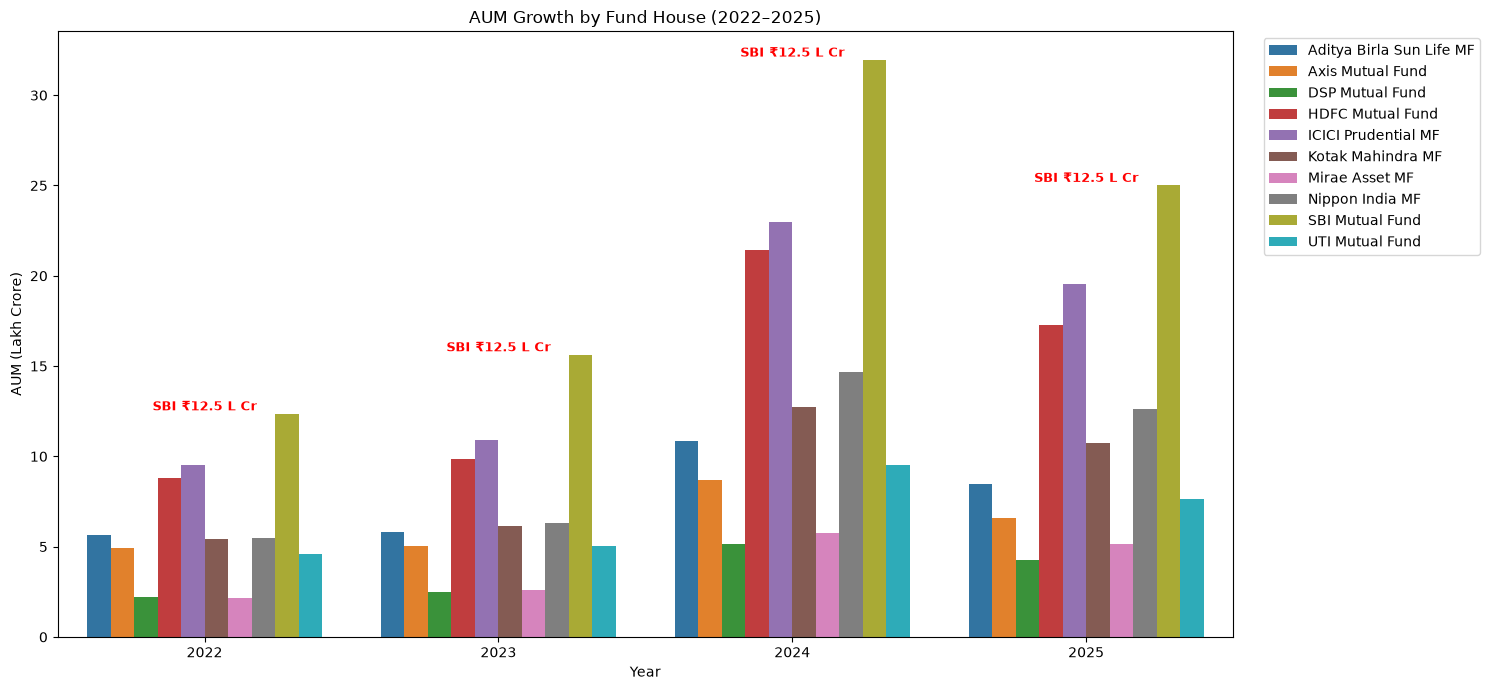

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

aum = pd.read_csv("../data/processed/aum_clean.csv")

aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

aum = aum[aum["year"].between(2022, 2025)]

yearly_aum = (
    aum.groupby(["year", "fund_house"])["aum_lakh_crore"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(15,7))

ax = sns.barplot(
    data=yearly_aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

# Highlight SBI 
sbi_data = yearly_aum[
    yearly_aum["fund_house"].str.contains("SBI", case=False, na=False)
]

for _, row in sbi_data.iterrows():

   plt.text(
    row["year"] - 2022,
    row["aum_lakh_crore"] + 0.2,
    "SBI ₹12.5 L Cr",
    ha="center",
    fontsize=9,
    color="red",
    fontweight="bold"
)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

# Save PNG
plt.savefig(
    "../reports/charts/2_aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#### SBI Mutual Fund maintained one of the highest AUM values during the study period.

### 3) SIP inflow time-series — monthly SIP trend Jan 2022 – Dec 2025. Annotate the ₹31,002 Cr all-time high (Dec 2025) using Plotly.

In [23]:
sip = pd.read_csv("../data/processed/sip_clean.csv")

sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

# Highlight Dec 2025 peak
fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr<br>All-Time-High<br>(Dec 2025)",
    showarrow=True,
    arrowhead=2,
    arrowsize=1.5,
    arrowwidth=2,
    arrowcolor="red",
    bgcolor="yellow",
    bordercolor="black",
    font=dict(size=12)
)

# Highlight peak point
fig.add_scatter(
    x=["2025-12-01"],
    y=[31002],
    mode="markers",
    marker=dict(
        size=12,
        color="red"
    ),
    name="All-Time High"
)

fig.update_layout(
    width=1200,
    height=600,
    hovermode="x unified",
    template="plotly_white"
)

fig.show()
# export as image 
fig.write_image(
    "../reports/charts/3_sip_trend.png",
    scale=3
)



#### Monthly SIP inflows increased over time and reached an all-time high of ₹31,002 Crore in December 2025.

### 4) Category inflow heatmap — months on X-axis, fund categories on Y-axis, net inflow as colour intensity using Seaborn.

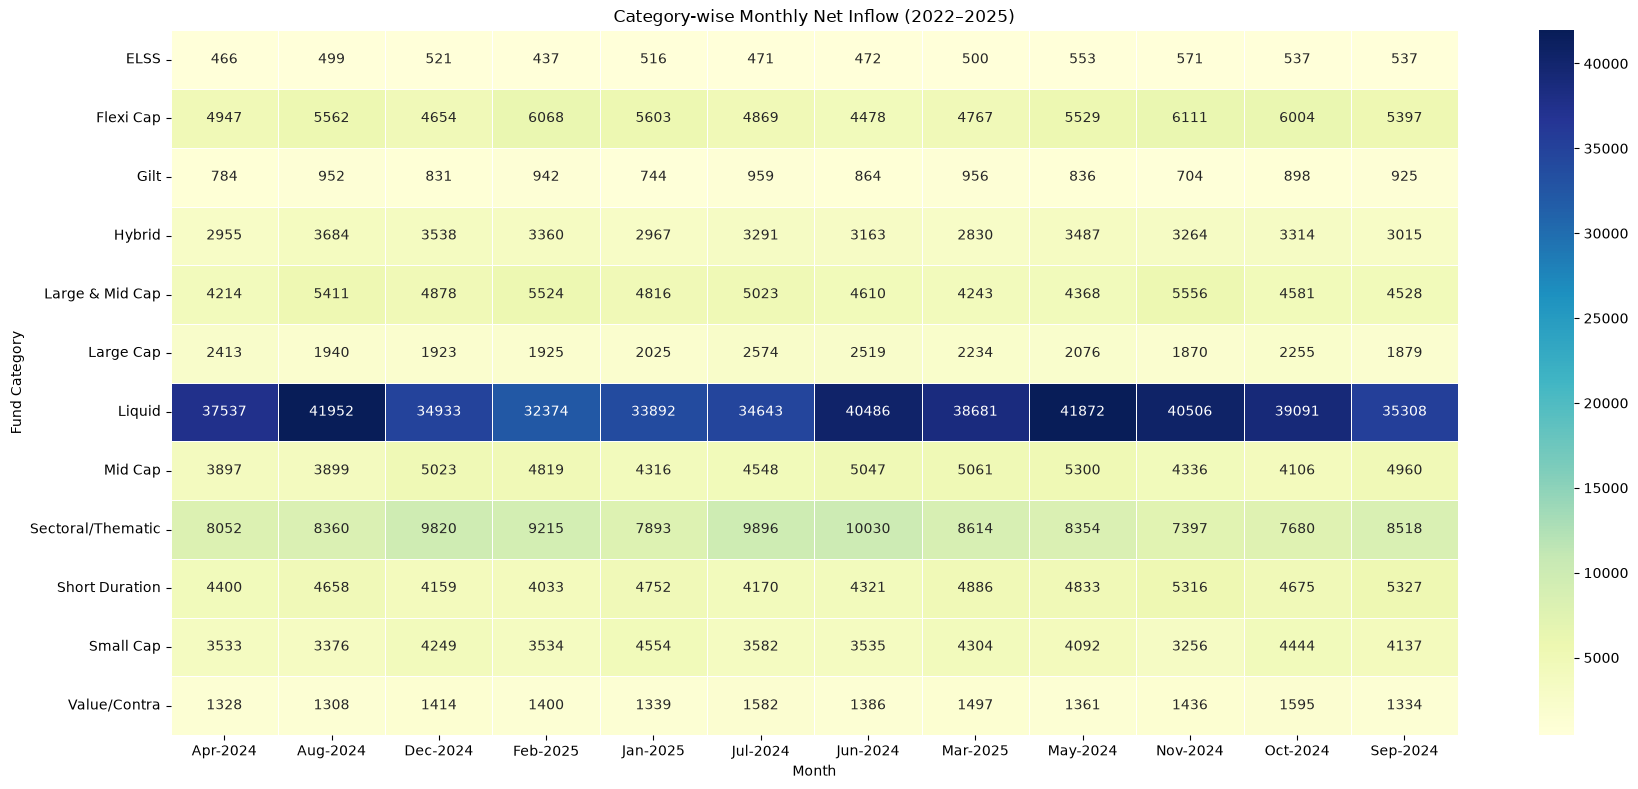

In [24]:
category = pd.read_csv("../data/processed/category_inflows_clean.csv")

category["month"] = pd.to_datetime(category["month"])
category["Month"] = category["month"].dt.strftime("%b-%Y")

# pivot table
heatmap_data = category.pivot_table(
    index="category",
    columns="Month",
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    annot=True,
    fmt=".0f"
)

plt.title("Category-wise Monthly Net Inflow (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
# import img
plt.savefig(
    "../reports/charts/4_category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#### Equity funds received higher net inflows compared to most other fund categories.

### 5) Investor demographics — A) age group distribution pie chart. B) SIP amount box plot by age group. C) Gender split.

#### A)

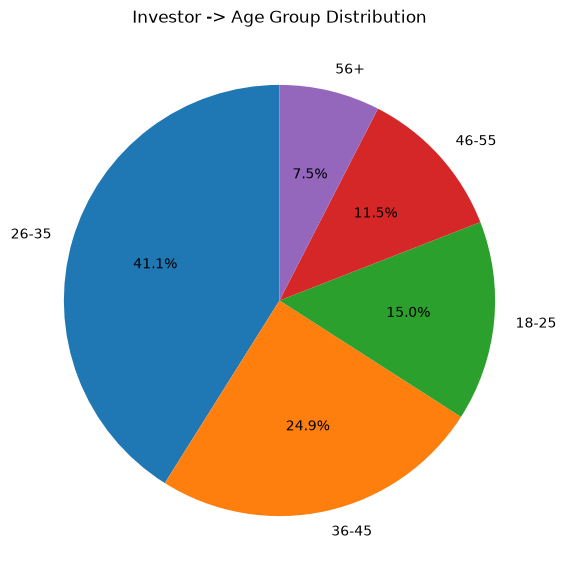

In [25]:
txn = pd.read_csv("../data/processed/investor_transactions_clean.csv")

age = txn["age_group"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age,
    labels=age.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor -> Age Group Distribution")
#import img 
plt.savefig(
    "../reports/charts/5_A_age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#### Most mutual fund investors belong to the 26–35 years age group.


### B)

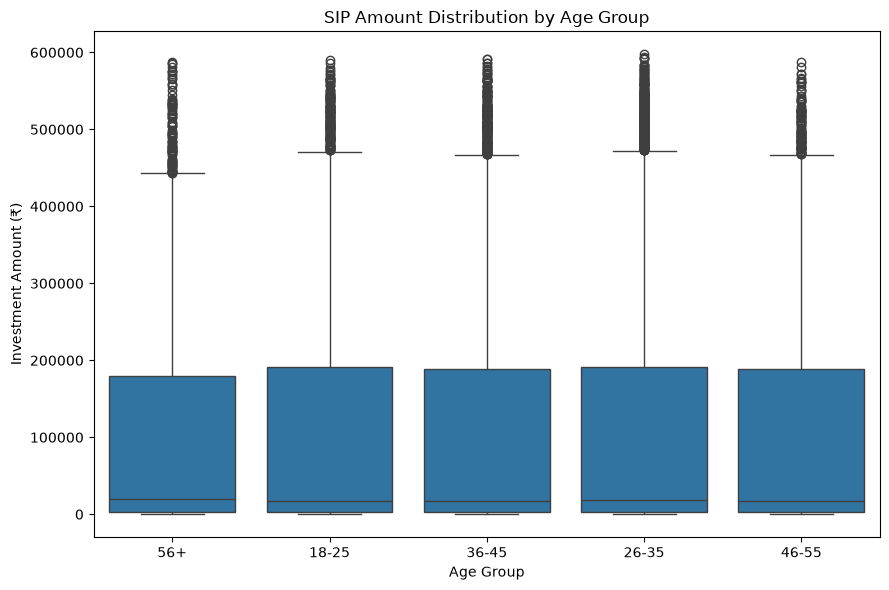

In [26]:
plt.figure(figsize=(9,6))

sns.boxplot(
    data=txn,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Investment Amount (₹)")

plt.tight_layout()

plt.savefig(
    "../reports/charts/5_B_sip_boxplot_age.png",
    dpi=300
)

plt.show()


### C)

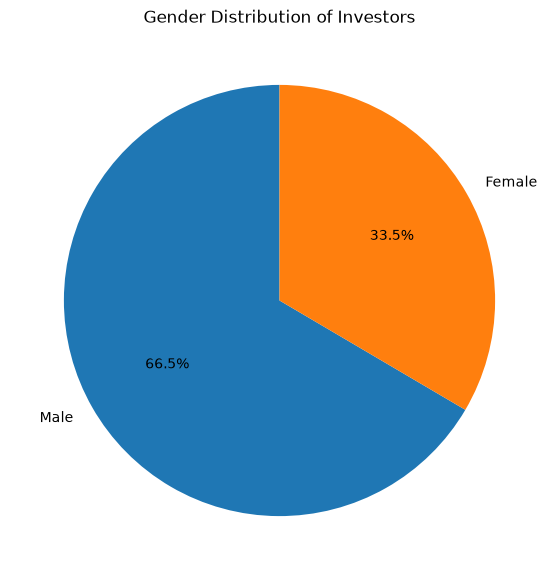

In [27]:
gender = txn["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")
# save the figure
plt.savefig(
    "../reports/charts/5_C_gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#### Male investors made a larger share of mutual fund investments than female investors.

### 6) Geographic distribution — A) horizontal bar chart of SIP amount by state. B) T30 vs B30 city tier pie chart.

### A)

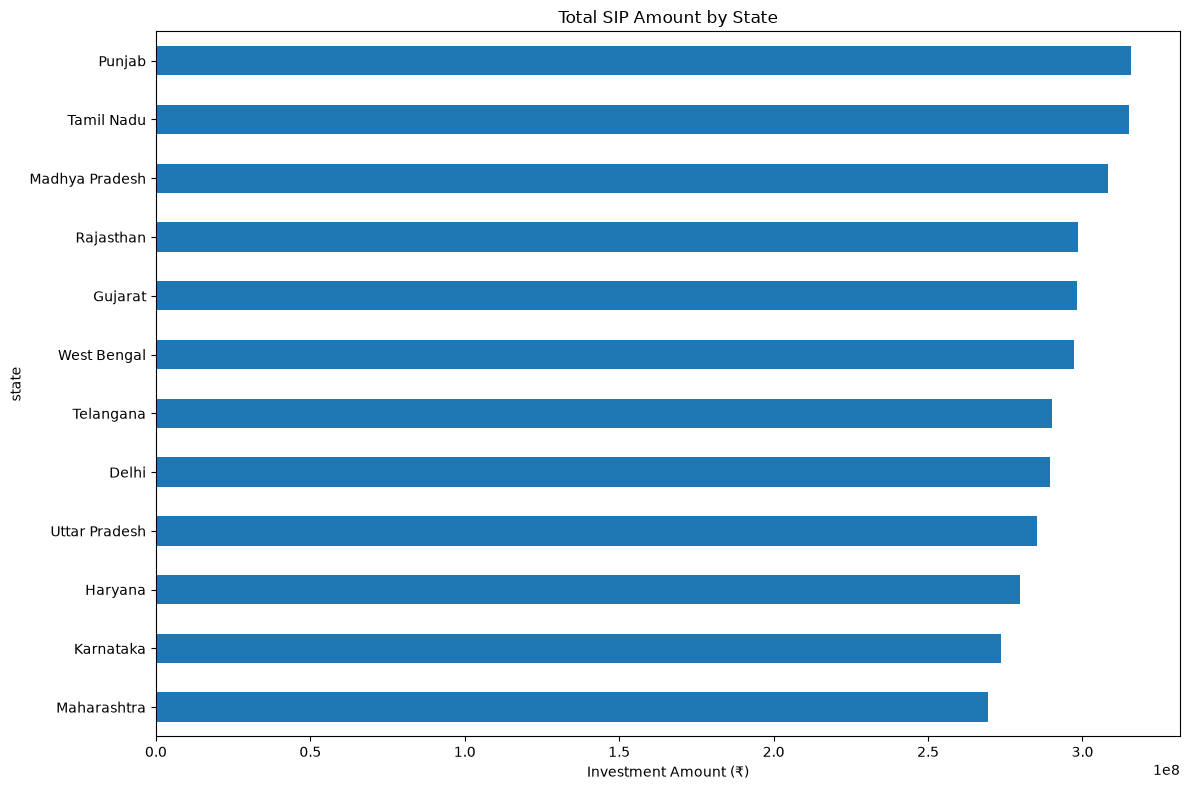

In [28]:
state = (
    txn.groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(12,8))

state.plot(
    kind="barh"
)

plt.title("Total SIP Amount by State")

plt.xlabel("Investment Amount (₹)")

plt.tight_layout()
#save the figure
plt.savefig(
    "../reports/charts/6_A_state_sip_distribution.png",
    dpi=300
)

plt.show()


#### Maharashtra recorded one of the highest SIP investment amounts among all states.

### B)

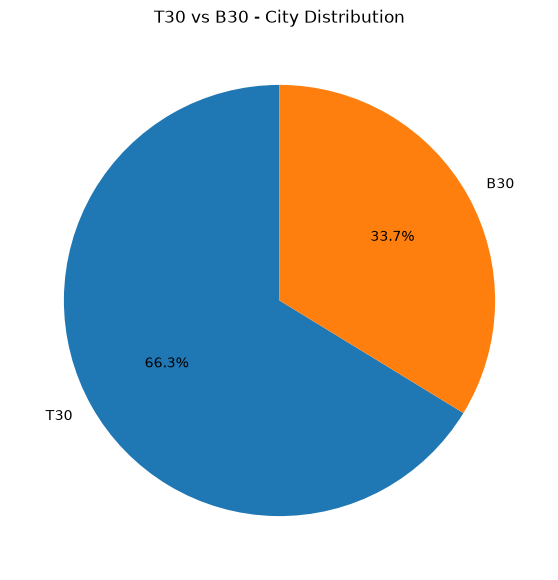

In [29]:
tier = txn["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 - City Distribution")
# export as image
plt.savefig(
    "../reports/charts/6_B_city_tier_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#### T30 cities contributed more investments than B30 cities.

### 7) Folio count growth — line chart from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025). Mark key milestones.


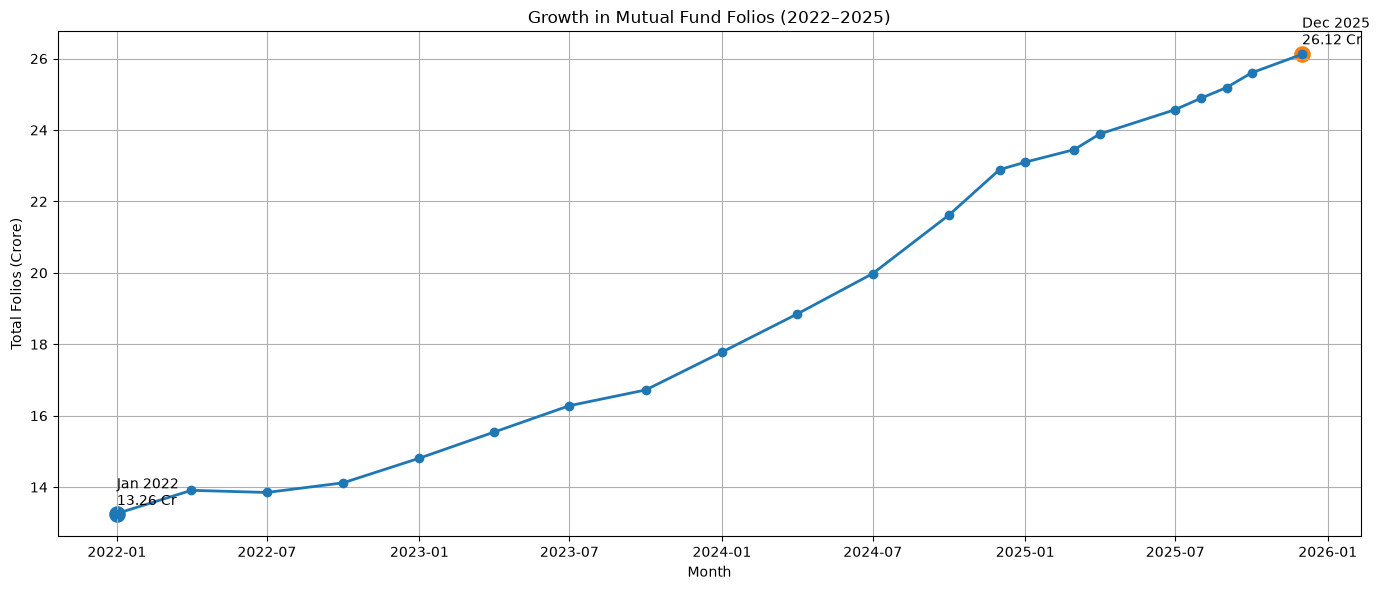

In [30]:
folio = pd.read_csv("../data/processed/folio_clean.csv")

folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Growth in Mutual Fund Folios (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

# Assign specific milestones
plt.scatter(pd.Timestamp("2022-01-01"),13.26,s=120)

plt.text(
    pd.Timestamp("2022-01-01"),
    13.5,
    "Jan 2022\n13.26 Cr",
    fontsize=10
)

plt.scatter(pd.Timestamp("2025-12-01"),26.12,s=120)

plt.text(
    pd.Timestamp("2025-12-01"),
    26.4,
    "Dec 2025\n26.12 Cr",
    fontsize=10
)

plt.grid(True)

plt.tight_layout()
# save the figure
plt.savefig(
    "../reports/charts/7_folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#### The total folio count increased from 13.26 Crore to 26.12 Crore, showing strong investor participation.

### 8) NAV return correlation matrix — compute pairwise correlation of daily returns for 10 selected funds. Seaborn heatmap.

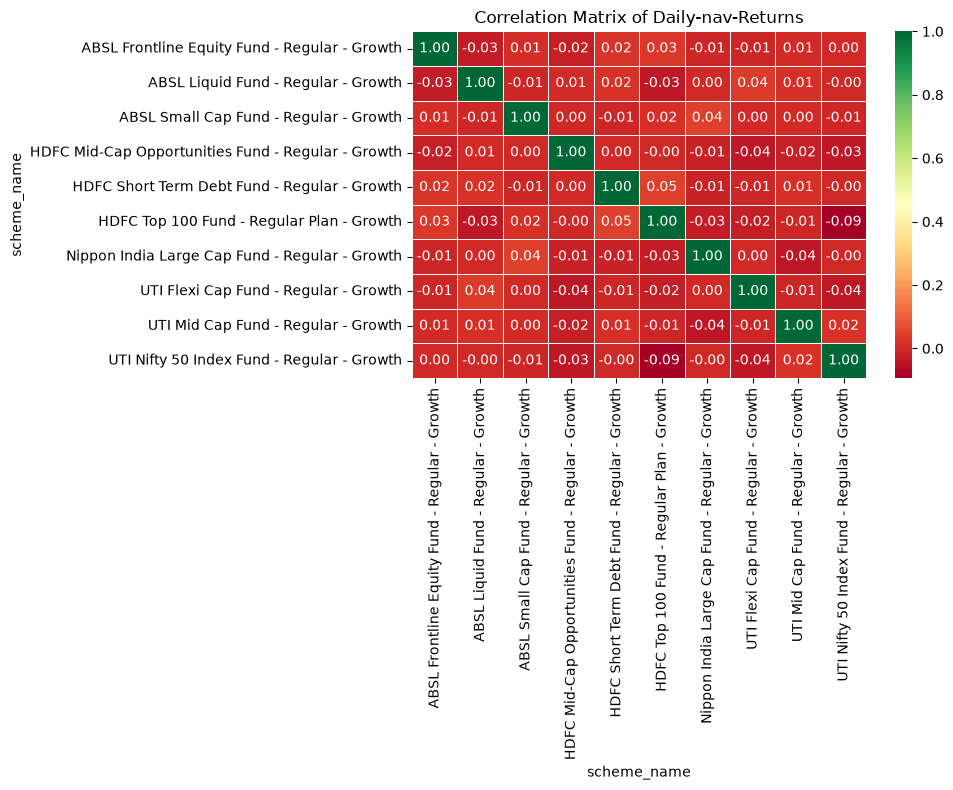

In [31]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")
fund = pd.read_csv("../data/processed/fund_master_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])

# Merge scheme-names
nav = nav.merge(
    fund[["amfi_code","scheme_name"]],
    on="amfi_code",
    how="left"
)
# select 1st 10 schemes
top10 = nav["scheme_name"].drop_duplicates().head(10)

nav10 = nav[
    nav["scheme_name"].isin(top10)
]

pivot = nav10.pivot_table(
    index="date",
    columns="scheme_name",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlGn",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily-nav-Returns")

plt.tight_layout()

plt.savefig(
    "../reports/charts/8_nav_correlation_heatmap.png",
    dpi=300
)

plt.show()


### 9) Sector allocation donut — aggregate sector weights from portfolio_holdings.csv across all equity funds.

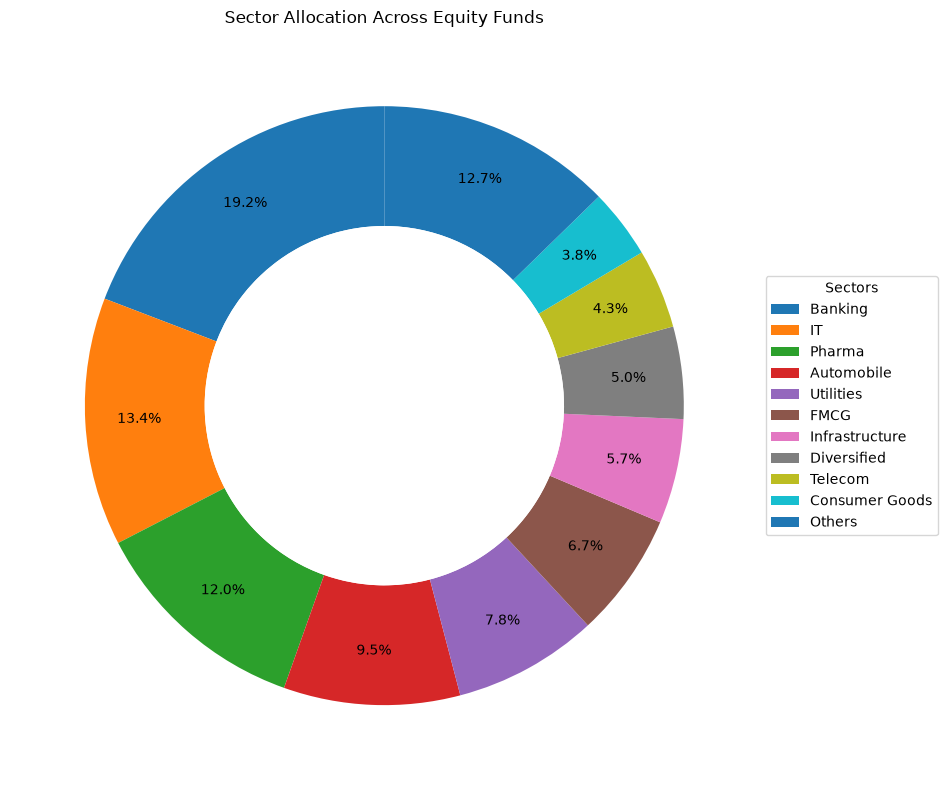

In [32]:
portfolio = pd.read_csv("../data/processed/portfolio_holdings_clean.csv")

# Aggregate sector weights
sector = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

top10 = sector.head(10)

others = sector.iloc[10:].sum()

if others > 0:
    top10["Others"] = others

# Plot
plt.figure(figsize=(10, 8))

wedges, texts, autotexts = plt.pie(
    top10,
    labels=None,                
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.82,           
    wedgeprops=dict(width=0.4)
)

# Donut hole
centre_circle = plt.Circle((0, 0), 0.60, fc="white")
plt.gca().add_artist(centre_circle)

# Legend outside
plt.legend(
    wedges,
    top10.index,
    title="Sectors",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Sector Allocation Across Equity Funds")

plt.tight_layout()

plt.savefig(
    "../reports/charts/9_sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#### Financial Services and IT had the highest allocation in mutual fund portfolios.